# Unsupervised Machine Learning for Clustering

## K-means

In [1]:
# Unsupervised, distance based, centroid based clustering algorithm

In [16]:
# Requiremnets
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
# Data set
preference = pd.read_csv('c:/jilliepython/video_preference.csv')
preference.head()

,news_hours,entertainment_hours,sports_hours,documentary_hours
0,6,6,19,12
1,19,17,7,15
2,14,1,11,3
3,10,16,3,4
4,7,10,4,4


### Choosing K by Elbow Method and Silhouette Score

In [ ]:
# Choosing the number of clusters: elbow method & silhouette score
K_values = range(2, 9)
distortions = []
sil_scores = []

for k in K_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(preference)
    distortions.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(preference, kmeans.labels_))

print("Distortions (Elbow Method):")
for k, d in zip(K_values, distortions):
    print(f"k={k}: {d:.2f}")

print("\nSilhouette Scores:")
for k, s in zip(K_values, sil_scores):
    print(f"k={k}: {s:.3f}")


Distortions (Elbow Method):
k=2: 110796.97
k=3: 94155.45
k=4: 79676.10
k=5: 71262.72
k=6: 64548.74
k=7: 58464.93
k=8: 51389.30

Silhouette Scores:
k=2: 0.181
k=3: 0.177
k=4: 0.203
k=5: 0.203
k=6: 0.202
k=7: 0.209
k=8: 0.234


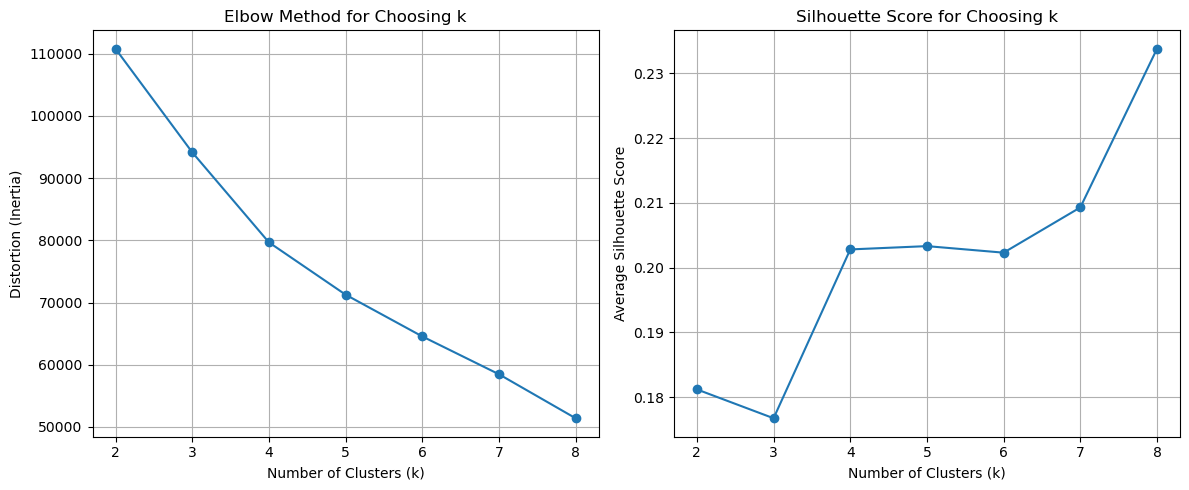

In [ ]:
# Plotting elbow and silhouette score
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(K_values, distortions, marker='o')
plt.title("Elbow Method for Choosing k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Distortion (Inertia)")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(K_values, sil_scores, marker='o')
plt.title("Silhouette Score for Choosing k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Average Silhouette Score")
plt.grid(True)

plt.tight_layout()
plt.show()



In [ ]:
# Elbow plot shows notable decreasing after 4
# Sihouette score jumps sharply from 3 to 4 and remains stable through 5 to 6
# K = 4

### K-means with K = 4

In [21]:
# Running K-Means with k = 4
k = 4
kmeans = KMeans(n_clusters=k, random_state=1234)
kmeans.fit(preference)

KMeans(n_clusters=4, random_state=1234)

In [22]:
# Retrieveing labels and centroids
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

In [23]:
# Adding cluster labels to the dataset
preference['cluster'] = labels
print(preference.head())

   news_hours  entertainment_hours  sports_hours  documentary_hours  cluster
0           6                    6            19                 12        2
1          19                   17             7                 15        1
2          14                    1            11                  3        0
3          10                   16             3                  4        1
4           7                   10             4                  4        1


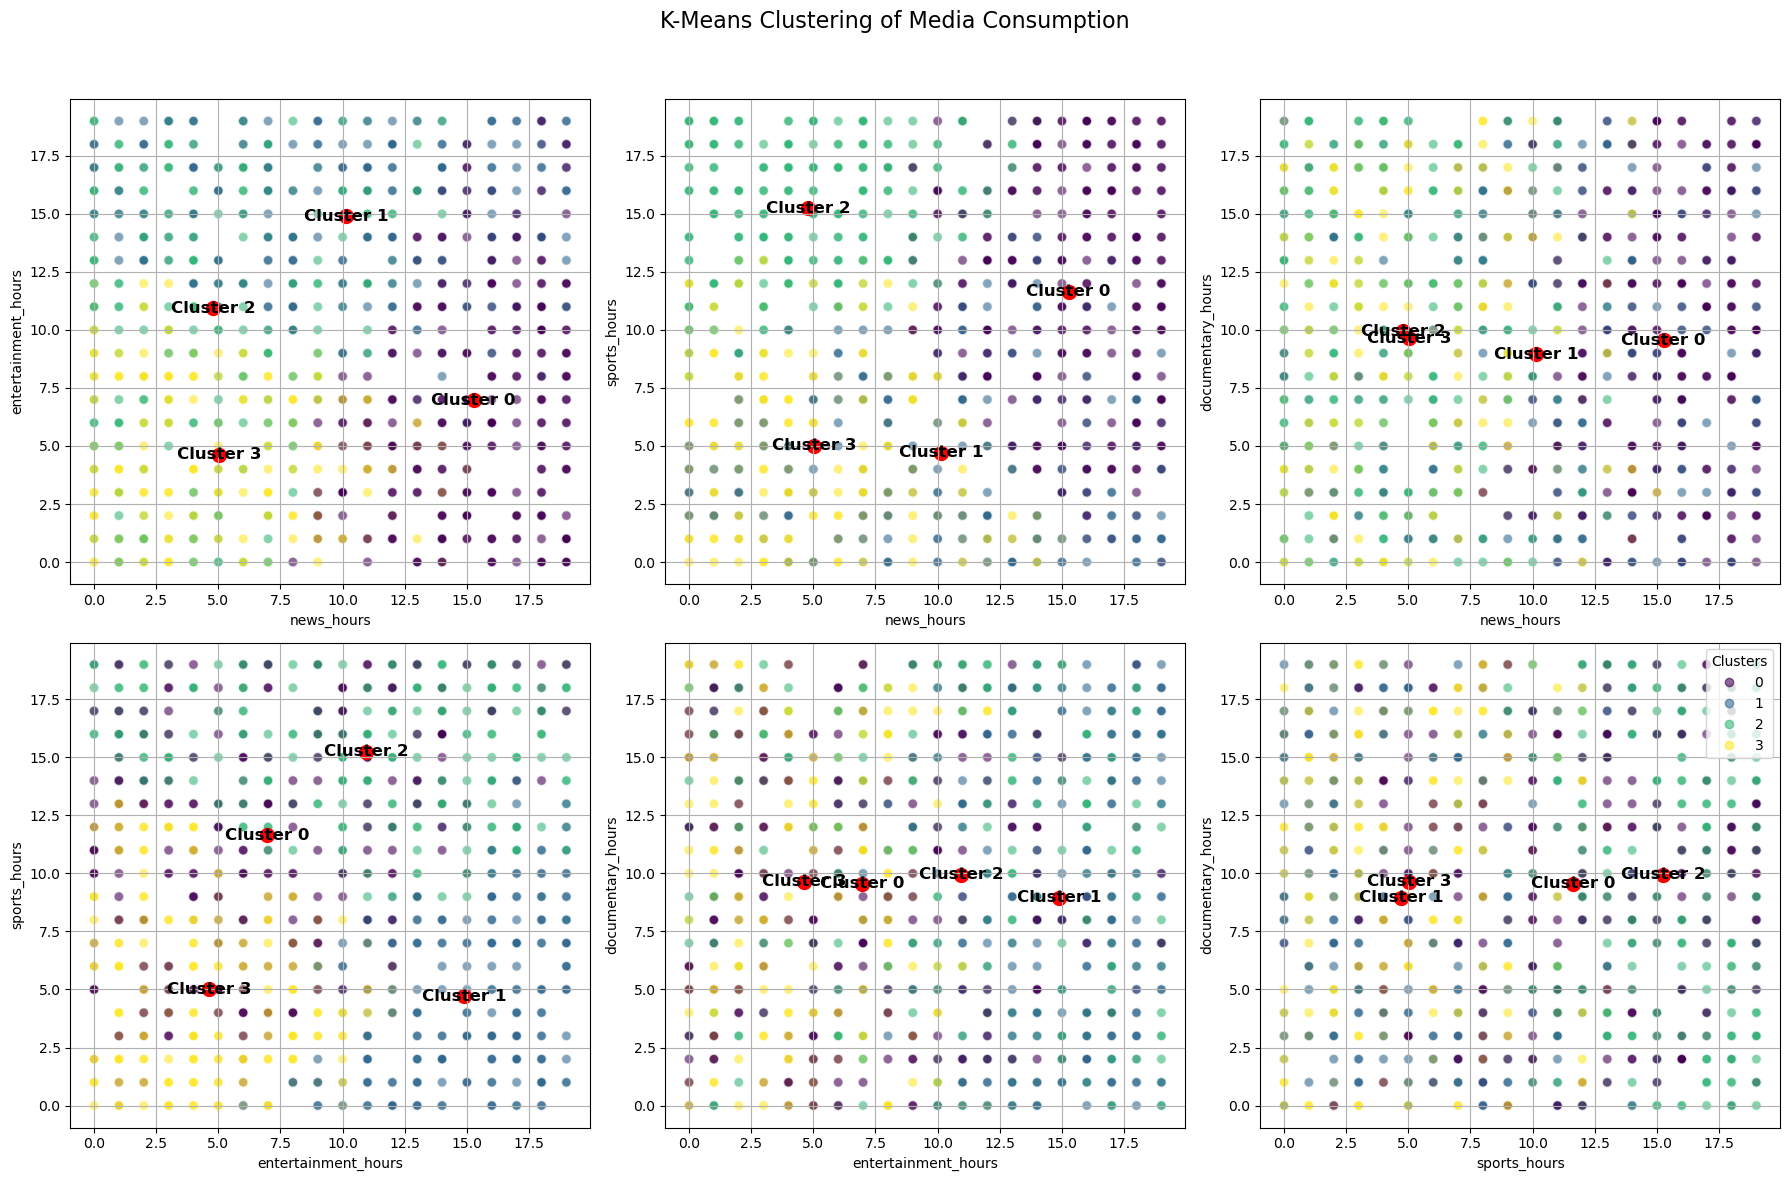

In [ ]:
# Visualizing clusters using all feature pairs
fig, axs = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('K-Means Clustering of Media Consumption', fontsize=16)

feature_pairs = [
    ('news_hours', 'entertainment_hours'),
    ('news_hours', 'sports_hours'),
    ('news_hours', 'documentary_hours'),
    ('entertainment_hours', 'sports_hours'),
    ('entertainment_hours', 'documentary_hours'),
    ('sports_hours', 'documentary_hours')
]

for ax, (feature1, feature2) in zip(axs.ravel(), feature_pairs):
    scatter = ax.scatter(
        preference[feature1],
        preference[feature2],
        c=labels, cmap='viridis',
        alpha=0.6, edgecolors='w', s=50
    )

    # Plot centroids
    ax.scatter(
        centroids[:, preference.columns.get_loc(feature1)],
        centroids[:, preference.columns.get_loc(feature2)],
        s=100, c='red', label='Centroids'
    )

    # Label centroids
    for idx, centroid in enumerate(centroids):
        ax.text(
            centroid[preference.columns.get_loc(feature1)],
            centroid[preference.columns.get_loc(feature2)],
            f'Cluster {idx}',
            color='black', fontsize=12,
            ha='center', va='center', weight='bold'
        )

    ax.set_xlabel(feature1)
    ax.set_ylabel(feature2)
    ax.grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.legend(*scatter.legend_elements(), title="Clusters", loc='upper right')
plt.show()

# Clusters show heavy overlap across all classes
# Consistent with low silhouette scores (~0.2)

## Principal Component Analysis (PCA)

In [ ]:
# Reducing dimensionality by projecting data onto orthogonal axes (principal components)
# that maximize variance, ordered by amount of variance explained (PC1 > PC2 > ...)

In [25]:
# Requiremnets
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [ ]:
# Data set
preference = pd.read_csv('c:/jilliepython/video_preference.csv')
preference.head()

In [27]:
# Selecting feature columns
feature_cols = ['news_hours', 'entertainment_hours', 'sports_hours', 'documentary_hours']
X = preference[feature_cols].values

In [29]:
# Standardizing features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [30]:
# Fitting PCA using all components (for loadings)
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

In [31]:
# Variance explained by each component
explained_variance = pca.explained_variance_ratio_
components = np.arange(1, len(explained_variance) + 1)

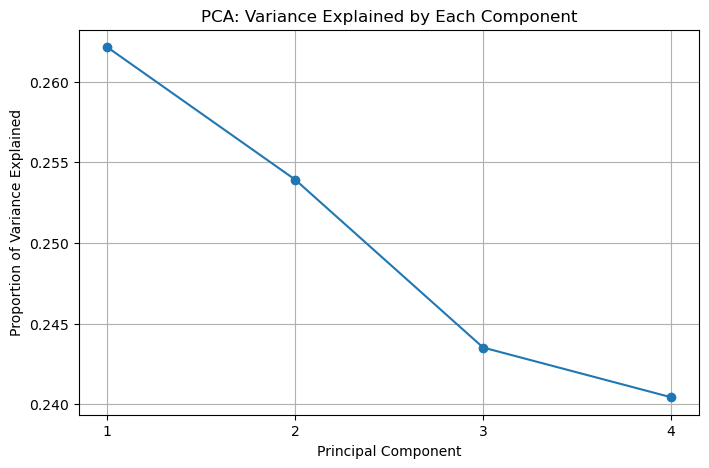

Proportion of variance explained by each component:
PC1: 0.262
PC2: 0.254
PC3: 0.244
PC4: 0.240

Cumulative variance explained by first 2 components: 0.516


In [ ]:
# Plotting the variance explained by each component
plt.figure(figsize=(8, 5))
plt.plot(components, explained_variance, marker='o')
plt.xticks(components)
plt.xlabel('Principal Component')
plt.ylabel('Proportion of Variance Explained')
plt.title('PCA: Variance Explained by Each Component')
plt.grid(True)
plt.show()

print("Proportion of variance explained by each component:")
for i, var in enumerate(explained_variance, start=1):
    print(f"PC{i}: {var:.3f}")

print(f"\nCumulative variance explained by first 2 components: {explained_variance[:2].sum():.3f}")

# Variance evenly spread across all 4 PCs (~25% each)
# Low cumulative variance (51.6% for PC1+PC2) confirms weak underlying structure


In [ ]:
# Loadings: how original variables contribute to each PC
loading_matrix = pca.components_.T  # shape: n_features x n_components

loadings_df = pd.DataFrame(
    loading_matrix,
    index=feature_cols,
    columns=[f'PC{i}' for i in range(1, len(feature_cols) + 1)]
)

print("\nPCA Loadings (Contribution of each variable to each PC):")
print(loadings_df.round(3))

# Loadings show no single variable dominating any PC (values spread ~0.3-0.7 across all four)
# Mixed associations per component


PCA Loadings (Contribution of each variable to each PC):
                       PC1    PC2    PC3    PC4
news_hours          -0.463 -0.508  0.684  0.246
entertainment_hours -0.586  0.357 -0.359  0.633
sports_hours        -0.287  0.723  0.486 -0.398
documentary_hours    0.600  0.302  0.409  0.617


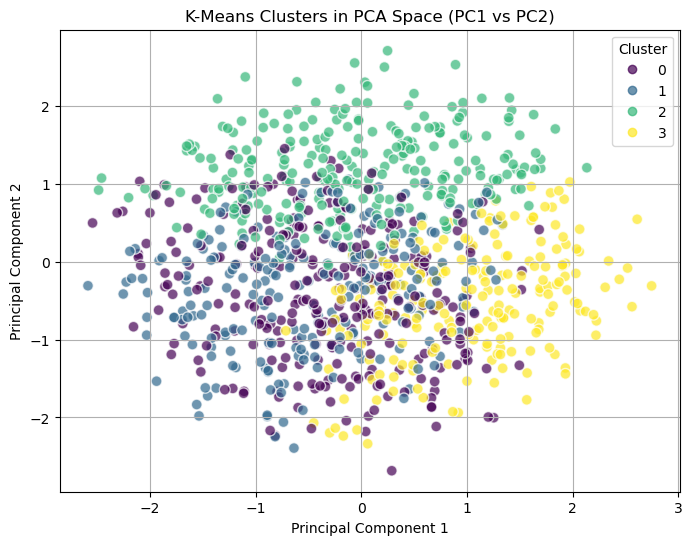

In [ ]:
# Adding PC1 and PC2 scores to the df (preference)
preference['PC1'] = X_pca[:, 0]
preference['PC2'] = X_pca[:, 1]

# 2D scatter: PC1 vs PC2 colored by K-Means cluster
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    preference['PC1'],
    preference['PC2'],
    c=preference['cluster'],
    cmap='viridis',
    alpha=0.7,
    edgecolors='w',
    s=60
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Clusters in PCA Space (PC1 vs PC2)')
plt.grid(True)

handles, labels_unique = scatter.legend_elements()
plt.legend(handles, labels_unique, title="Cluster", loc='best')

plt.show()

# Partial separation along PC2 (cluster 2 top vs clusters 1/3 bottom)
# Overlap of cluster 0 across entire space, confirming weak cluster structure
